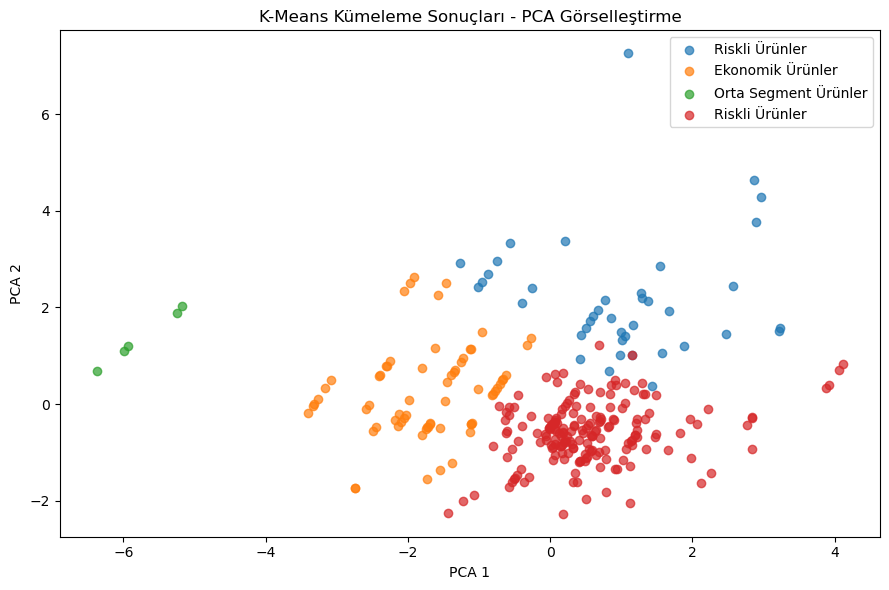

PCA küme grafiği oluşturuldu.
Grafik: grafikler/kmeans_pca_grafigi.png
Dosya: kmeans_pca_sonuclari.xlsx


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

GIRIS_DOSYASI = "kmeans_sonuclari.xlsx"
CIKTI_KLASORU = "grafikler"

os.makedirs(CIKTI_KLASORU, exist_ok=True)

df = pd.read_excel(GIRIS_DOSYASI)

ozellikler = [
    "fiyat_sayisal",
    "puan_sayisal",
    "ram_gb",
    "ssd_gb",
    "ek_urun_sayisi",
    "yorum_memnuniyet_skoru",
    "pozitiflik_orani",
    "risk_orani"
]

ozellikler = [col for col in ozellikler if col in df.columns]

X = df[ozellikler].copy()
X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["pca_1"] = pca_result[:, 0]
df["pca_2"] = pca_result[:, 1]

plt.figure(figsize=(9, 6))

for kume in sorted(df["kume_no"].unique()):
    alt_df = df[df["kume_no"] == kume]
    etiket = alt_df["kume_etiketi"].iloc[0] if "kume_etiketi" in alt_df.columns else f"Küme {kume}"

    plt.scatter(
        alt_df["pca_1"],
        alt_df["pca_2"],
        label=etiket,
        alpha=0.7
    )

plt.title("K-Means Kümeleme Sonuçları - PCA Görselleştirme")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/kmeans_pca_grafigi.png", dpi=300)
plt.show()

df.to_excel("kmeans_pca_sonuclari.xlsx", index=False)

print("PCA küme grafiği oluşturuldu.")
print("Grafik: grafikler/kmeans_pca_grafigi.png")
print("Dosya: kmeans_pca_sonuclari.xlsx")